# Chapter 8: Flowlines, Risers, and Pipeline Hydraulics

This notebook demonstrates pipeline hydraulic calculations using NeqSim's
**PipeBeggsAndBrills** model for multiphase flow in oil and gas production systems.

**Topics covered:**
- Multiphase gas-oil pipeline pressure drop modeling
- Effect of pipeline diameter on pressure drop
- Flow rate vs pressure drop relationship
- Liquid holdup behavior with gas velocity
- Pipeline capacity curves for sizing

In [1]:
# Execute against the selected, compiled NeqSim source checkout.
import os
import sys
from pathlib import Path
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import jpype

if not os.environ.get("NEQSIM_PROJECT_ROOT"):
    raise RuntimeError("Set NEQSIM_PROJECT_ROOT to the NeqSim source checkout before running.")
PROJECT_ROOT = Path(os.environ["NEQSIM_PROJECT_ROOT"]).resolve()
if not (PROJECT_ROOT / "devtools" / "neqsim_dev_setup.py").exists():
    raise RuntimeError("NEQSIM_PROJECT_ROOT must contain devtools/neqsim_dev_setup.py.")
sys.path.insert(0, str(PROJECT_ROOT / "devtools"))
from neqsim_dev_setup import neqsim_init, neqsim_classes
ns = neqsim_classes(neqsim_init(project_root=PROJECT_ROOT, recompile=False, verbose=False))
jneqsim = jpype.JPackage("neqsim")
NEQSIM_MODE = "devtools"
NOTEBOOK_PATH = Path(globals().get("__vsc_ipynb_file__", Path.cwd() / "ch07_flowlines_figures.ipynb")).resolve()
BOOK_ROOT = NOTEBOOK_PATH.parents[3]
FIGURES_DIR = NOTEBOOK_PATH.parent.parent / "figures"
FIGURES_DIR.mkdir(exist_ok=True)
sys.path.insert(0, str(BOOK_ROOT / "devtools"))
from book_figure_tools import configure_figures, export_figure_summary
configure_figures()
print(f"NeqSim source: {PROJECT_ROOT}; Python: {sys.executable}")

# Named NeqSim class bindings used throughout the chapter.
SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
SystemPrEos = jneqsim.thermo.system.SystemPrEos
SystemSrkCPAstatoil = jneqsim.thermo.system.SystemSrkCPAstatoil
ThermodynamicOperations = jneqsim.thermodynamicoperations.ThermodynamicOperations
Stream = jneqsim.process.equipment.stream.Stream
Separator = jneqsim.process.equipment.separator.Separator
ThreePhaseSeparator = jneqsim.process.equipment.separator.ThreePhaseSeparator
Compressor = jneqsim.process.equipment.compressor.Compressor
Cooler = jneqsim.process.equipment.heatexchanger.Cooler
Heater = jneqsim.process.equipment.heatexchanger.Heater
HeatExchanger = jneqsim.process.equipment.heatexchanger.HeatExchanger
Mixer = jneqsim.process.equipment.mixer.Mixer
Splitter = jneqsim.process.equipment.splitter.Splitter
ThrottlingValve = jneqsim.process.equipment.valve.ThrottlingValve
Pump = jneqsim.process.equipment.pump.Pump
Expander = jneqsim.process.equipment.expander.Expander
Recycle = jneqsim.process.equipment.util.Recycle
ProcessSystem = jneqsim.process.processmodel.ProcessSystem

# Physical verification uses the same model state, source and interpreter.
sys.path.insert(0, str(BOOK_ROOT / "verification" / "scientific_revision"))
from notebook_physics_checks import PhysicsChecks
_physics = PhysicsChecks(NOTEBOOK_PATH)


All NeqSim classes imported OK
NeqSim source: C:\Users\solbraa\OneDrive - NTNU\Documents\ChatGPT\NeqSim; Python: C:\Users\solbraa\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\python.exe


In [2]:
import matplotlib.pyplot as plt
import numpy as np

# jneqsim is bound to the source JVM in the setup cell.

SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
ThermodynamicOperations = jneqsim.thermodynamicoperations.ThermodynamicOperations
Stream = jneqsim.process.equipment.stream.Stream
PipeBeggsAndBrills = jneqsim.process.equipment.pipeline.PipeBeggsAndBrills
ProcessSystem = jneqsim.process.processmodel.ProcessSystem


## 8.1 Create Multiphase Gas-Oil Fluid

We model a typical wet gas / gas-condensate production fluid with light
hydrocarbons and a small amount of condensate (nC10) at 60 °C and 80 bara.

In [3]:
def create_pipeline_fluid(T_C=60.0, P_bara=80.0):
    """Create a gas-condensate fluid for pipeline calculations."""
    fluid = SystemSrkEos(273.15 + T_C, P_bara)
    fluid.addComponent("nitrogen", 0.02)
    fluid.addComponent("CO2", 0.03)
    fluid.addComponent("methane", 0.75)
    fluid.addComponent("ethane", 0.08)
    fluid.addComponent("propane", 0.05)
    fluid.addComponent("i-butane", 0.02)
    fluid.addComponent("n-butane", 0.02)
    fluid.addComponent("n-pentane", 0.01)
    fluid.addComponent("nC10", 0.02)
    fluid.setMixingRule("classic")
    fluid.setMultiPhaseCheck(True)
    return fluid

# Quick test
test_fluid = create_pipeline_fluid()
ops = ThermodynamicOperations(test_fluid)
ops.TPflash()
test_fluid.initProperties()
assert _physics.state(test_fluid, 'calculation_cell_4:test_fluid', candidate=False)
print(f"Number of phases: {test_fluid.getNumberOfPhases()}")
print(f"Gas density: {test_fluid.getPhase('gas').getDensity('kg/m3'):.2f} kg/m3")


Number of phases: 2
Gas density: 72.90 kg/m3


## 8.2 Figure 1: Pressure Drop vs Pipeline Diameter

At a fixed flow rate, larger diameter pipelines produce lower pressure drops.
This is the fundamental trade-off in pipeline sizing: larger pipe costs more
but reduces compression requirements.

  Diameter 4 inch failed: java.lang.RuntimeException: Failed to run unit operation pipeline


ch07_flowlines_figures.ipynb:cell6:44: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


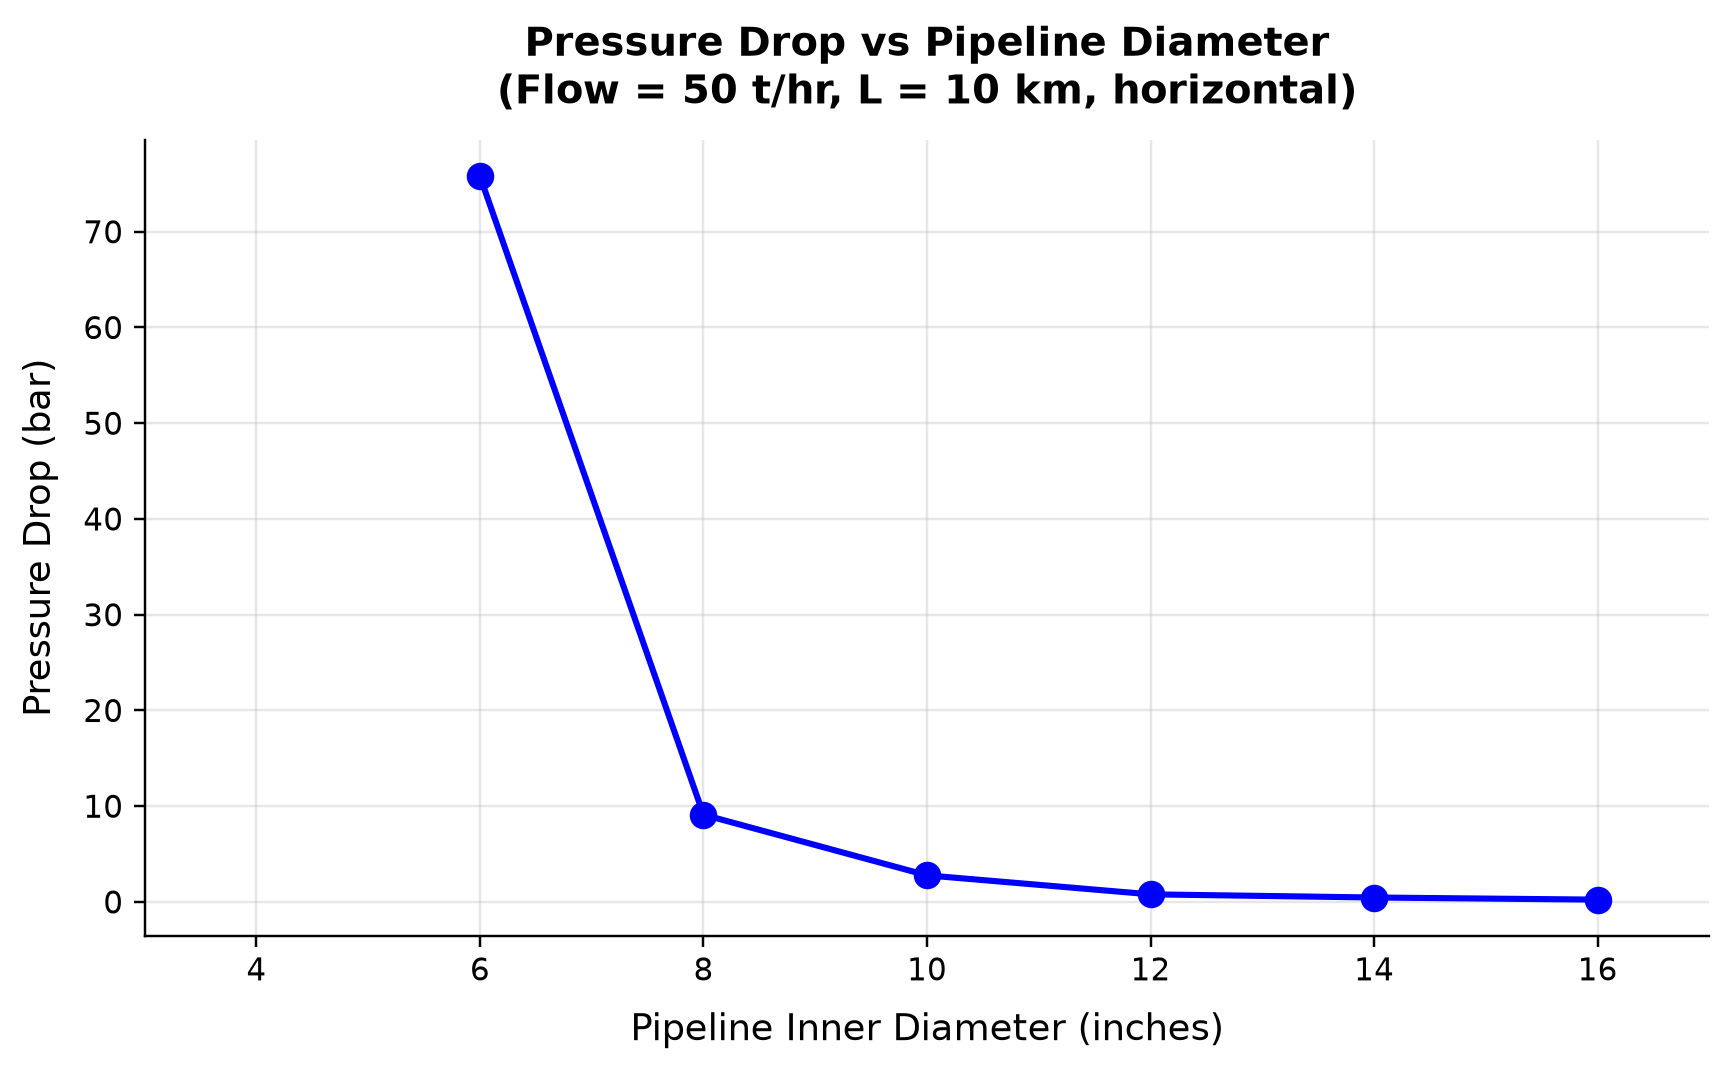

In [4]:
diameters_inch = np.array([4, 6, 8, 10, 12, 14, 16])
diameters_m = diameters_inch * 0.0254  # Convert to meters
pressure_drops = []
flow_rate_kghr = 50000.0  # Fixed flow rate
pipe_length = 10000.0  # 10 km pipeline

for diam_m in diameters_m:
    fluid = create_pipeline_fluid(60.0, 80.0)
    feed = Stream("feed", fluid)
    feed.setFlowRate(flow_rate_kghr, "kg/hr")
    feed.setTemperature(273.15 + 60.0, "K")
    feed.setPressure(80.0, "bara")

    pipe = PipeBeggsAndBrills("pipeline", feed)
    pipe.setDiameter(diam_m)
    pipe.setLength(pipe_length)
    pipe.setElevation(0.0)
    pipe.setNumberOfIncrements(20)

    process = ProcessSystem()
    process.add(feed)
    process.add(pipe)
    try:
        process.run()
        assert _physics.run(process, 'calculation_cell_6:process', candidate=True)
        dp = pipe.getPressureDrop()
        pressure_drops.append(float(dp))
    except Exception as e:
        print(f"  Diameter {diam_m*39.37:.0f} inch failed: {e}")
        pressure_drops.append(float('nan'))

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(diameters_inch, pressure_drops, 'bo-', linewidth=2, markersize=8)
ax.set_xlabel('Pipeline Inner Diameter (inches)', fontsize=12)
ax.set_ylabel('Pressure Drop (bar)', fontsize=12)
ax.set_title(f'Pressure Drop vs Pipeline Diameter\n'
             f'(Flow = {flow_rate_kghr/1000:.0f} t/hr, L = {pipe_length/1000:.0f} km, horizontal)',
             fontsize=13)
ax.grid(True, alpha=0.3)
ax.set_xlim(3, 17)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig01_pressure_drop_vs_diameter.png", dpi=220, bbox_inches="tight")
plt.show()


**Executed-figure discussion.** Pressure Drop spans 0.2395–75.79 bar across the plotted cases. Gaps retain undefined phase quantities or hydraulic states that fail the stated operating boundary; they are not interpolated.

A larger bore reduces velocity and frictional pressure loss at fixed rate; density, holdup and friction-factor changes modify the simple diameter scaling. A small increase in bore can recover pressure margin, but excessive size may affect low-rate liquid transport and project cost. Select a diameter from the feasible arrival-pressure envelope and check turndown, holdup, erosion and installation constraints.


**Discussion:** Pressure drop decreases sharply with increasing diameter,
approximately following a $\Delta P \propto D^{-5}$ relationship for turbulent flow.
Going from 6-inch to 10-inch pipe typically reduces pressure drop by an order of
magnitude. This trade-off between pipe cost and operating pressure is central to
pipeline design.

## 8.3 Figure 2: Pressure Drop vs Flow Rate

For a fixed pipeline diameter, pressure drop increases non-linearly with flow rate,
roughly as $\Delta P \propto Q^{1.8}$ in the turbulent regime.

ch07_flowlines_figures.ipynb:cell9:39: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


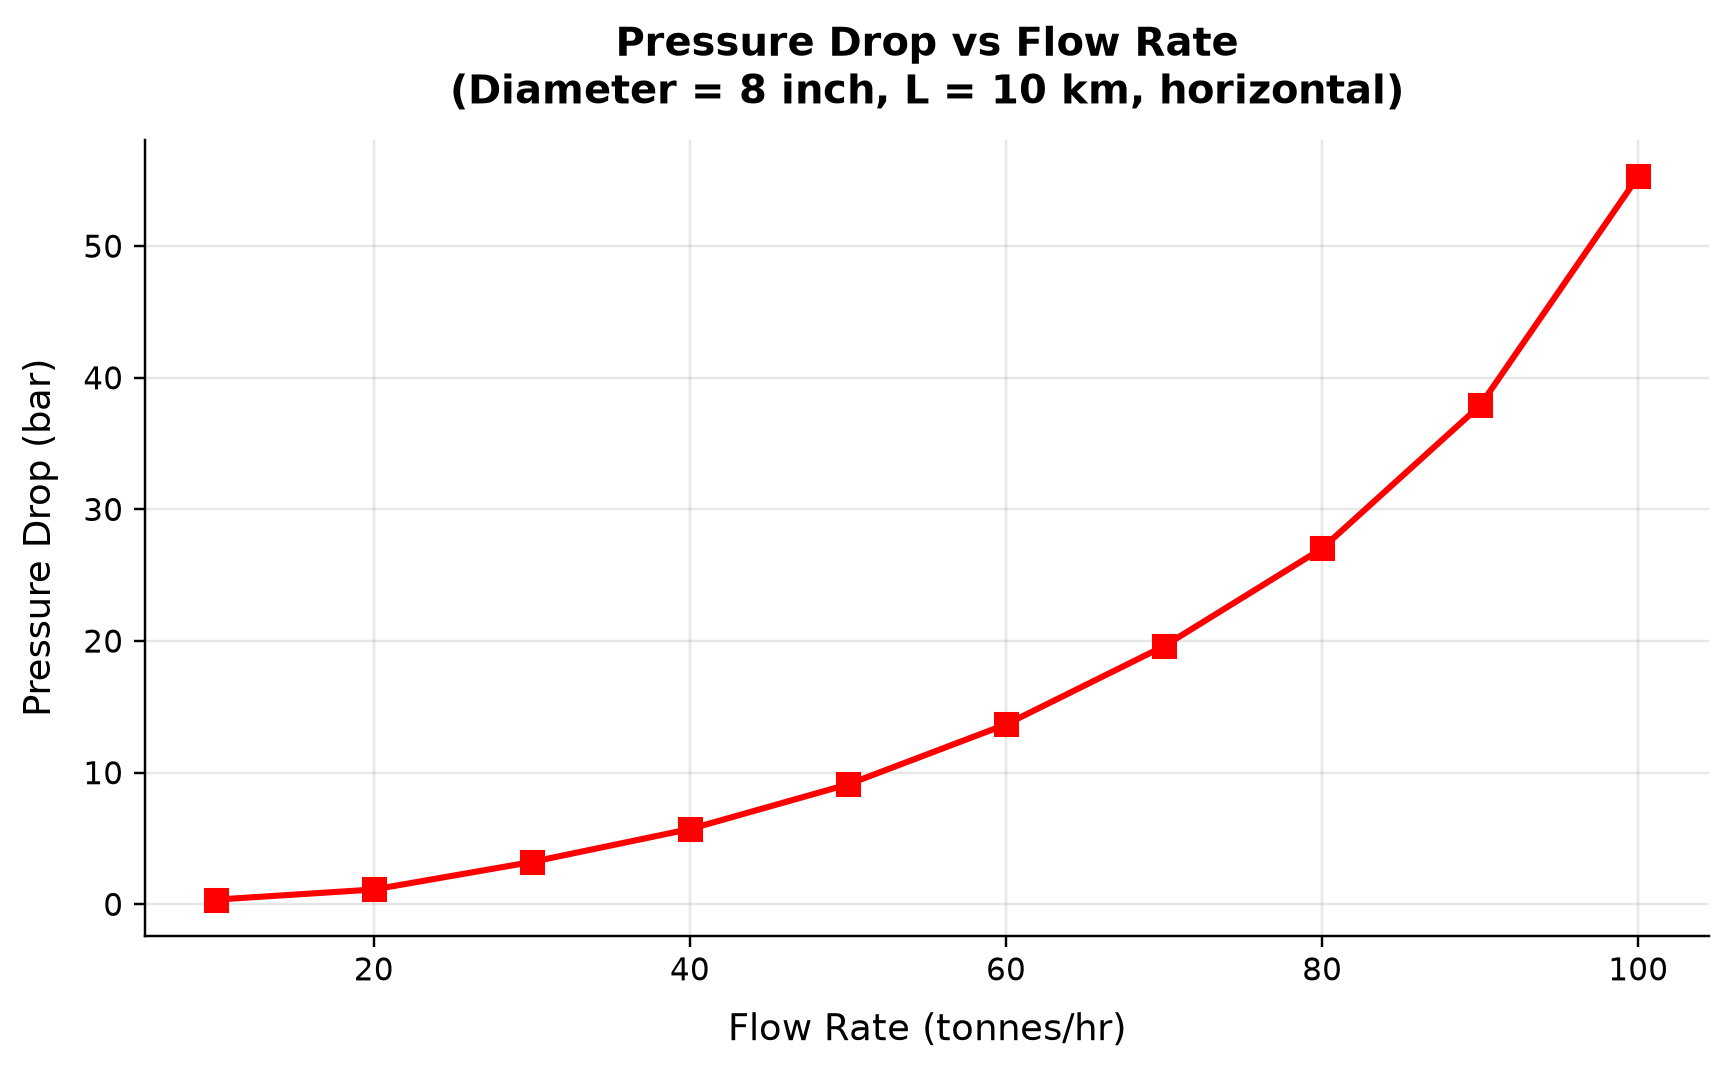

In [5]:
flow_rates_kghr = np.linspace(10000, 100000, 10)
dp_vs_flow = []
pipe_diam_m = 0.2032  # 8 inch

for flow in flow_rates_kghr:
    fluid = create_pipeline_fluid(60.0, 80.0)
    feed = Stream("feed", fluid)
    feed.setFlowRate(float(flow), "kg/hr")
    feed.setTemperature(273.15 + 60.0, "K")
    feed.setPressure(80.0, "bara")

    pipe = PipeBeggsAndBrills("pipeline", feed)
    pipe.setDiameter(pipe_diam_m)
    pipe.setLength(pipe_length)
    pipe.setElevation(0.0)
    pipe.setNumberOfIncrements(20)

    process = ProcessSystem()
    process.add(feed)
    process.add(pipe)
    try:
        process.run()
        assert _physics.run(process, 'calculation_cell_9:process', candidate=True)
        dp_vs_flow.append(float(pipe.getPressureDrop()))
    except Exception:
        dp_vs_flow.append(float('nan'))

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(flow_rates_kghr / 1000, dp_vs_flow, 'rs-', linewidth=2, markersize=7)
ax.set_xlabel('Flow Rate (tonnes/hr)', fontsize=12)
ax.set_ylabel('Pressure Drop (bar)', fontsize=12)
ax.set_title(f'Pressure Drop vs Flow Rate\n'
             f'(Diameter = 8 inch, L = {pipe_length/1000:.0f} km, horizontal)',
             fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig02_pressure_drop_vs_flow.png", dpi=220, bbox_inches="tight")
plt.show()


**Executed-figure discussion.** Pressure Drop spans 0.3547–55.31 bar across the plotted cases.

Raising mass flow increases velocity, friction and possibly acceleration losses as the gas expands along the line. The pressure-drop trend can steepen near the hydraulic limit; a failed forward solve is not a valid high-flow data point. Bracket the feasible flow interval, retain failure diagnostics and solve the arrival-pressure boundary directly when determining capacity.


**Discussion:** The non-linear increase in pressure drop with flow rate illustrates
why production systems often become pipeline-limited. Doubling the flow rate more
than doubles the pressure drop, which can lead to capacity constraints when
available driving pressure is limited.

## 8.4 Figure 3: Liquid Holdup vs Gas Superficial Velocity

As gas velocity increases, the liquid holdup decreases because the gas phase
carries liquid droplets more efficiently. We vary the gas-to-liquid ratio to
demonstrate this effect.

ch07_flowlines_figures.ipynb:cell12:58: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


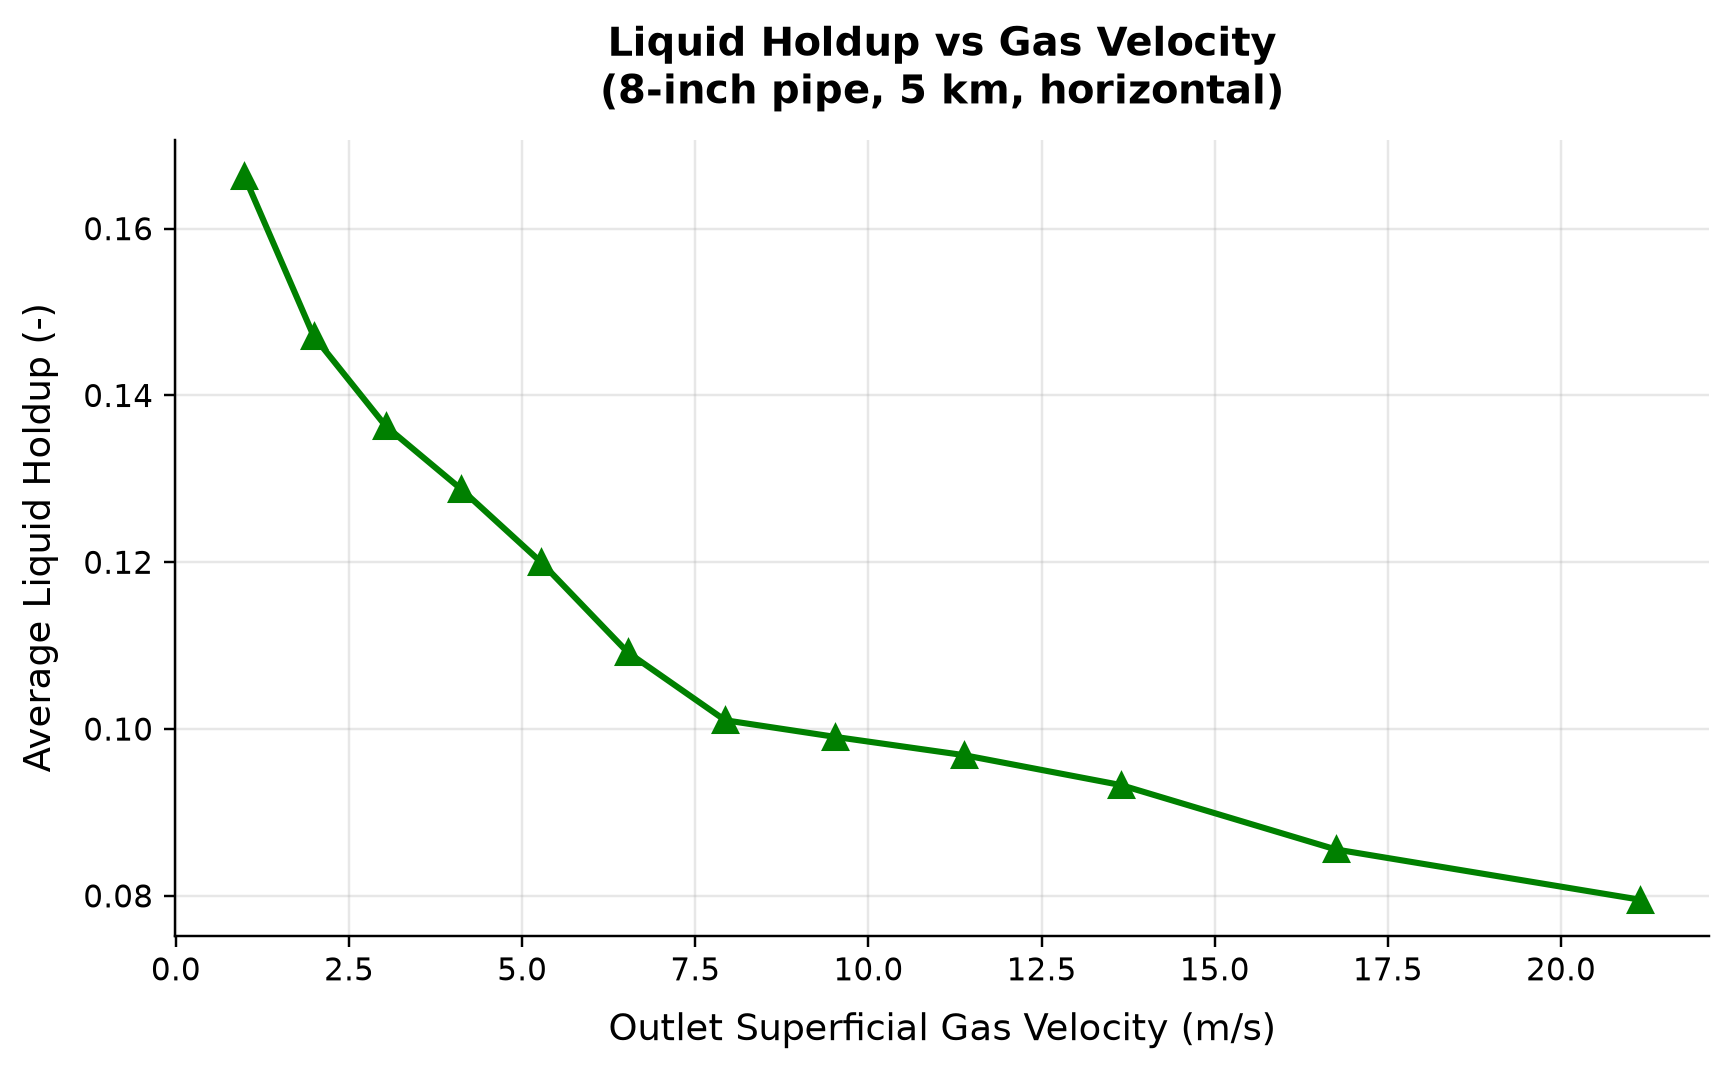

In [6]:
# Vary flow rate in a fixed-diameter pipe to change superficial velocities
flow_rates_sweep = np.linspace(10000, 120000, 12)
holdups = []
gas_velocities = []

for flow in flow_rates_sweep:
    fluid = create_pipeline_fluid(60.0, 80.0)
    feed = Stream("feed", fluid)
    feed.setFlowRate(float(flow), "kg/hr")
    feed.setTemperature(273.15 + 60.0, "K")
    feed.setPressure(80.0, "bara")

    pipe = PipeBeggsAndBrills("pipeline", feed)
    pipe.setDiameter(0.2032)  # 8 inch
    pipe.setLength(5000.0)  # 5 km
    pipe.setElevation(0.0)
    pipe.setNumberOfIncrements(10)

    process = ProcessSystem()
    process.add(feed)
    process.add(pipe)
    try:
        process.run()
        assert _physics.run(process, 'calculation_cell_12:process', candidate=True)
        # Get holdup profile and take the average
        holdup_profile = list(pipe.getLiquidHoldupProfileList())
        if len(holdup_profile) > 0:
            avg_holdup = sum(float(h) for h in holdup_profile) / len(holdup_profile)
        else:
            avg_holdup = float('nan')
        holdups.append(avg_holdup)

        # Estimate superficial gas velocity from outlet stream
        outlet = pipe.getOutletStream()
        outlet_fluid = outlet.getThermoSystem()
        outlet_fluid.initProperties()
        assert _physics.state(outlet_fluid, 'calculation_cell_12:outlet_fluid', candidate=True)
        if outlet_fluid.hasPhaseType("gas"):
            gas_density = float(outlet_fluid.getPhase("gas").getDensity("kg/m3"))
            # Use the actual phase superficial-velocity profile, not a volume-to-mass approximation.
            sup_gas_vel = float(list(pipe.getGasSuperficialVelocityProfile())[-1])
            gas_velocities.append(sup_gas_vel)
        else:
            gas_velocities.append(float('nan'))
    except Exception:
        holdups.append(float('nan'))
        gas_velocities.append(float('nan'))

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(gas_velocities, holdups, 'g^-', linewidth=2, markersize=8)
ax.set_xlabel('Outlet Superficial Gas Velocity (m/s)', fontsize=12)
ax.set_ylabel('Average Liquid Holdup (-)', fontsize=12)
ax.set_title('Liquid Holdup vs Gas Velocity\n(8-inch pipe, 5 km, horizontal)', fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig03_liquid_holdup.png", dpi=220, bbox_inches="tight")
plt.show()


**Executed-figure discussion.** Average Liquid Holdup spans 0.07955–0.1663 across the plotted cases.

Gas shear and liquid slip compete with gravity to determine the amount of liquid retained in the pipe. Holdup is a local flow-correlation result and differs from the inlet liquid fraction; it affects both hydrostatic loss and liquid inventory. Compare the selected correlation with representative operating data and examine the low-gas-rate regime for liquid accumulation.


**Discussion:** As gas velocity increases, liquid holdup decreases because faster
gas entrains and carries liquid more efficiently. At low gas velocities, liquid
accumulates at the pipe bottom (stratified flow), while at high velocities,
the flow transitions to annular or mist flow with minimal holdup. This has
important implications for pipeline pigging, slugging, and terrain-induced
liquid accumulation.

## 8.5 Figure 4: Pipeline Capacity Curve

For a given available pressure differential (e.g., 20 bar), what is the
maximum throughput for each pipeline diameter? This is the fundamental
capacity curve used in pipeline sizing.

ch07_flowlines_figures.ipynb:cell15:57: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


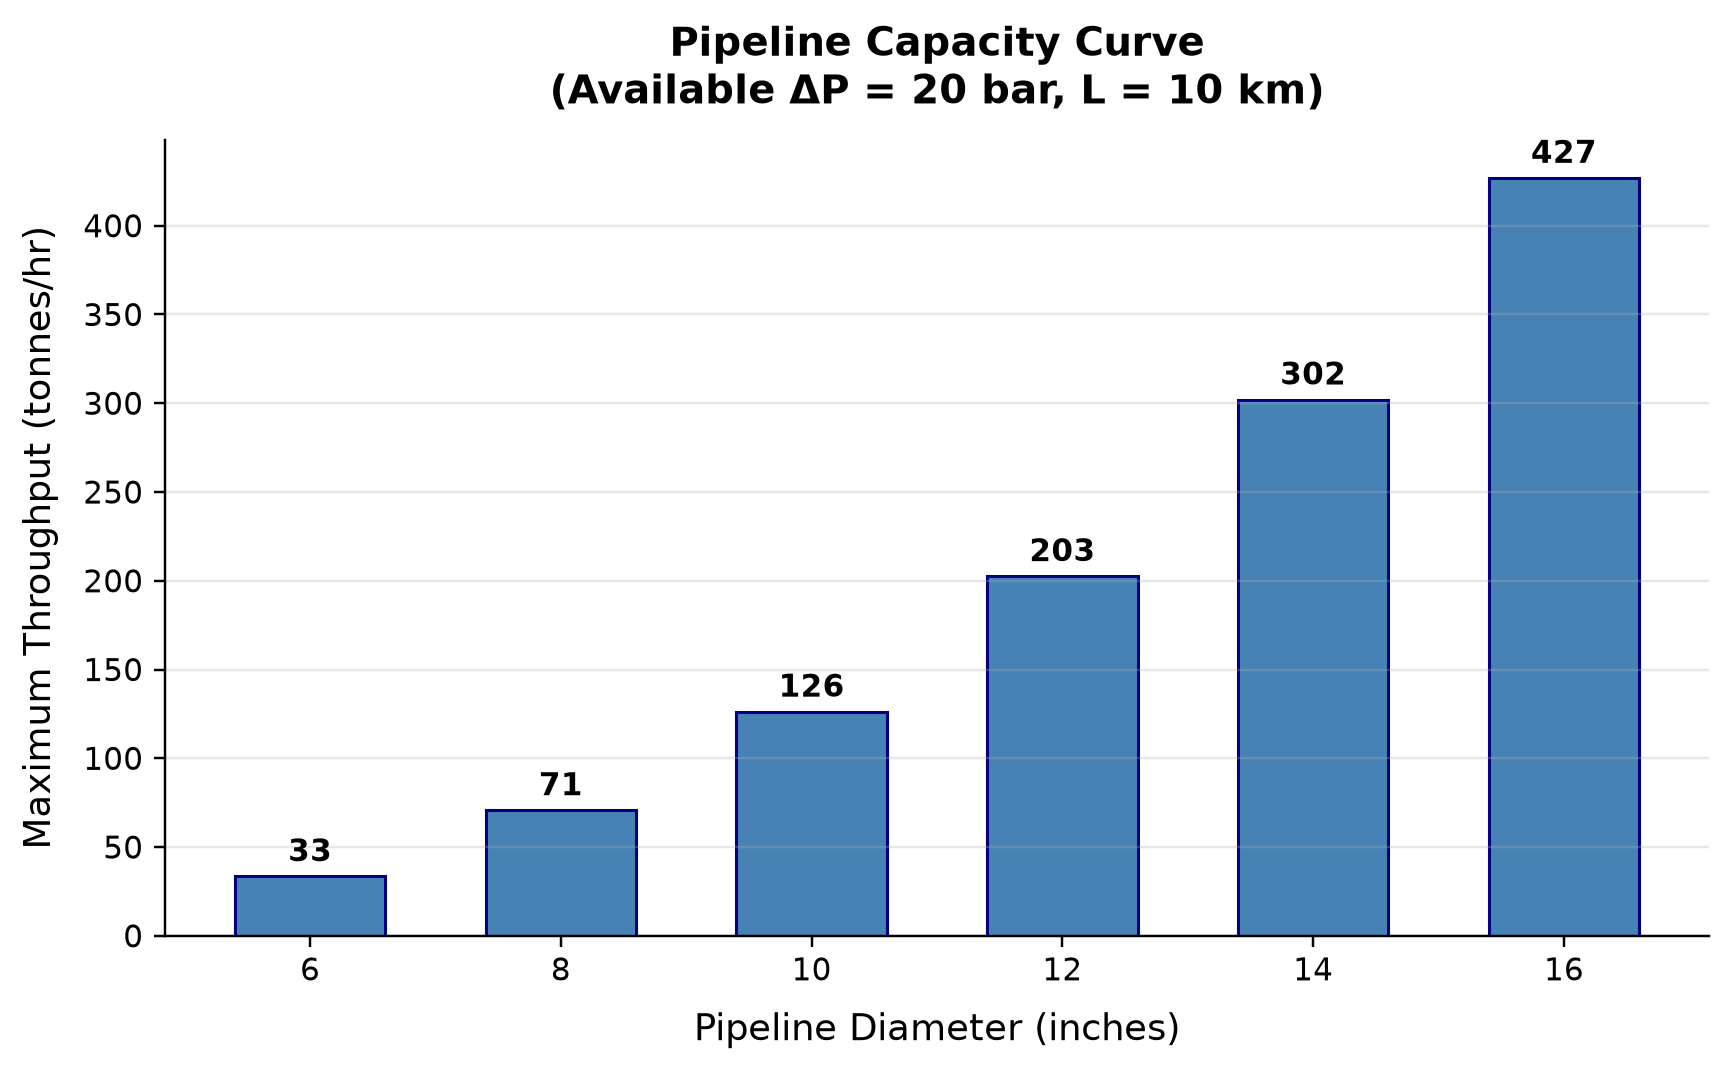

In [7]:
available_dp = 20.0  # Available pressure drop (bar)
diameters_cap_inch = np.array([6, 8, 10, 12, 14, 16])
diameters_cap_m = diameters_cap_inch * 0.0254
max_flows = []

for diam_m in diameters_cap_m:
    # Binary search for flow rate that gives available_dp
    low_flow, high_flow = 5000.0, 1500000.0
    best_flow = low_flow
    for _ in range(15):  # 15 iterations for convergence
        mid_flow = (low_flow + high_flow) / 2.0
        fluid = create_pipeline_fluid(60.0, 80.0)
        feed = Stream("feed", fluid)
        feed.setFlowRate(mid_flow, "kg/hr")
        feed.setTemperature(273.15 + 60.0, "K")
        feed.setPressure(80.0, "bara")

        pipe = PipeBeggsAndBrills("pipeline", feed)
        pipe.setDiameter(float(diam_m))
        pipe.setLength(pipe_length)
        pipe.setElevation(0.0)
        pipe.setNumberOfIncrements(15)

        process = ProcessSystem()
        process.add(feed)
        process.add(pipe)
        try:
            process.run()
            assert _physics.run(process, 'calculation_cell_15:process', candidate=True)
            dp = float(pipe.getPressureDrop())
            if dp < available_dp:
                low_flow = mid_flow
                best_flow = mid_flow
            else:
                high_flow = mid_flow
        except Exception:
            high_flow = mid_flow
    assert best_flow < 1499000.0, "Increase search upper bound; no capacity boundary found"
    max_flows.append(best_flow / 1000.0)  # Convert to tonnes/hr

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(diameters_cap_inch.astype(str), max_flows, color='steelblue', edgecolor='navy', width=0.6)
ax.set_xlabel('Pipeline Diameter (inches)', fontsize=12)
ax.set_ylabel('Maximum Throughput (tonnes/hr)', fontsize=12)
ax.set_title(f'Pipeline Capacity Curve\n'
             f'(Available ΔP = {available_dp:.0f} bar, L = {pipe_length/1000:.0f} km)',
             fontsize=13)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, v in enumerate(max_flows):
    ax.text(i, v + max(max_flows)*0.02, f'{v:.0f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig04_pipeline_capacity.png", dpi=220, bbox_inches="tight")
plt.show()


**Executed-figure discussion.** The sampled pipe diameters span 6–16 inches. Bisection finds throughputs of 33.42–426.88 t/hr at the 20 bar pressure-loss allowance; the search upper bound was checked to lie beyond the capacity boundary.

The hydraulic capacity is a boundary solution: the maximum feasible rate satisfying the available pressure-drop or arrival-pressure constraint. If the numerical search stops at its rate bound, the resulting point is a bound-limited result rather than a demonstrated pipeline limit. Expand the bracket where needed and report active pressure limits, residuals and the feasibility of the final trial.


**Discussion:** The capacity curve shows that pipeline throughput increases
dramatically with diameter — approximately as $Q_{max} \propto D^{2.5}$.
Doubling the pipe diameter from 8 to 16 inches can increase capacity by roughly
5-6 times. This is why pipeline sizing is one of the most impactful early
decisions in field development, as it directly determines the peak production
rate the system can sustain.

## Summary

Key takeaways from this chapter:

1. **Pressure drop scales strongly with diameter** — small increases in pipe size
   yield large reductions in friction loss.
2. **Pressure drop is non-linear with flow rate** — systems become pressure-limited
   well before geometric limits are reached.
3. **Liquid holdup decreases with gas velocity** — higher gas rates improve liquid
   transport but may cause erosion and vibration.
4. **Pipeline capacity** is determined by the interplay of available pressure
   differential, fluid properties, diameter, and length.

## Numerical output and figure provenance
The following table is extracted from the plotted numerical data. Each saved figure has an adjacent CSV and JSON record; missing points remain visible and are not replaced by interpolated results. Extrema summarize the sampled operating envelope, and are not independent validation of the model.


In [8]:
figure_results = export_figure_summary(NOTEBOOK_PATH)
print(figure_results.to_string(index=False, float_format=lambda value: f'{value:.6g}'))


                             Figure  Panel  Series                  Output / unit   Minimum  Maximum  Finite points  Missing points
fig01_pressure_drop_vs_diameter.png      1 Curve 1            Pressure Drop (bar)  0.239466  75.7931              6               1
    fig02_pressure_drop_vs_flow.png      1 Curve 1            Pressure Drop (bar)  0.354725  55.3089             10               0
            fig03_liquid_holdup.png      1 Curve 1      Average Liquid Holdup (-) 0.0795475 0.166279             12               0
        fig04_pipeline_capacity.png      1  Bars 1 Maximum Throughput (tonnes/hr)   33.4236  426.883              6               0


## Physical verification and its limits
The assertions above test the calculated states and steady-state conservation laws. Rejected operating candidates remain excluded; they do not become synthetic outputs. The chapter-specific checks below state the applicable limits. Independent reference-fluid and analytic benchmarks are recorded separately in `verification/scientific_revision/benchmark_results.json`. Passing these checks does not establish field calibration or an installed equipment rating.


In [9]:
from chapter_specific_checks import validate_chapter
assert validate_chapter(_physics, globals())
assert _physics.finish()


Physics verification: 223 distinct checks, 6764 evaluations; 0 rejected nonphysical candidates.


## Physical verification and scope

Hydraulic domains, holdup and diameter conversion. Hydrostatic and no-flow limits do not validate Beggs-Brill against multiphase field data.

The final code cell checks the computed cases against explicit physical, analytical or constraint criteria. A passed conservation check establishes internal consistency; it does not establish field accuracy. Independent reference values, actual model results, units, acceptance tolerances and source provenance are retained in the [benchmark notebook](../../../verification/scientific_revision/36_benchmark_validation.ipynb), [benchmark results](../../../verification/scientific_revision/benchmark_results.json) and [chapter validation ledger](../../../verification/scientific_revision/notebook_physics_review.md).
